In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

student_name = "Aisy Jibril Cordero"
student_id = "TUPM-25-0354"

id_num = int(student_id[-3:])

color1 = f"#{ (id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{ (id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

print(f"Color 1: {color1}")
print(f"Color 2: {color2}")

Color 1: #ae26ea
Color 2: #c47288


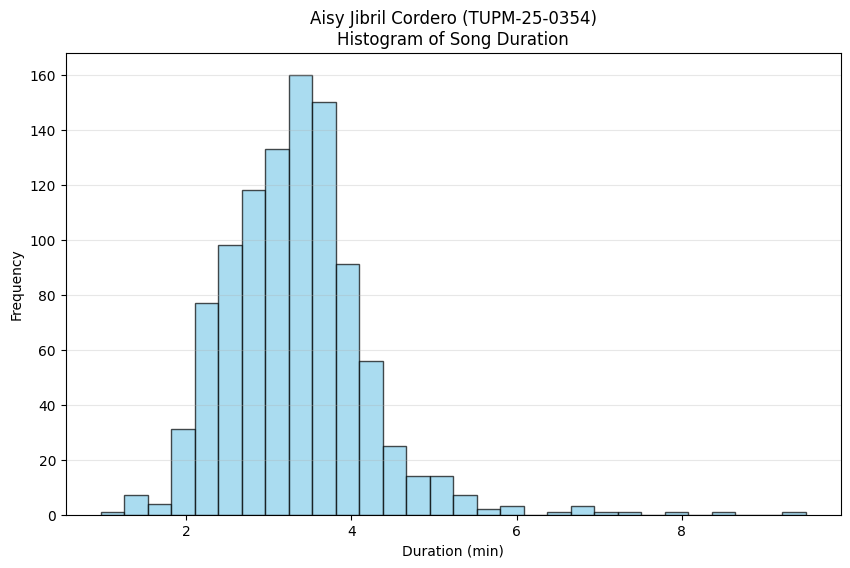

In [15]:
import matplotlib.pyplot as plt

# You don't need to create the column because it's already there!
# Just make sure student_name and student_id are defined

plt.figure(figsize=(10, 6))

# Use the existing 'duration_min' column
df['duration_min'].plot(kind='hist', bins=30, color='skyblue', edgecolor='black', alpha=0.7)

plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

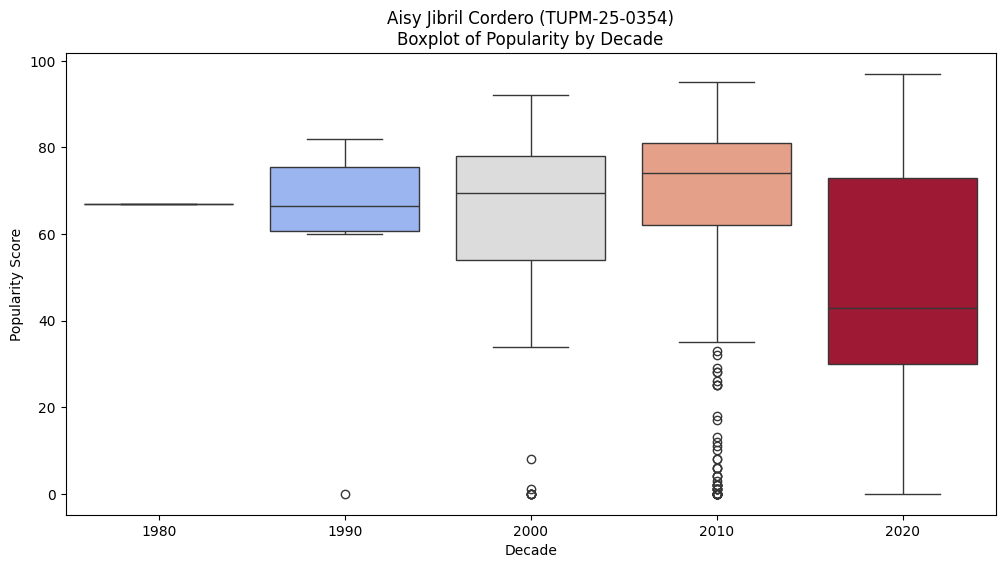

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('spotify_top_1000_tracks.csv')

student_name = "Aisy Jibril Cordero"
student_id = "TUPM-25-0354"


df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year


df = df.dropna(subset=['year'])


df['decade'] = (df['year'].astype(int) // 10) * 10


plt.figure(figsize=(12, 6))


sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm', hue='decade', legend=False)


plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade")
plt.xlabel("Decade")
plt.ylabel("Popularity Score")

plt.show()

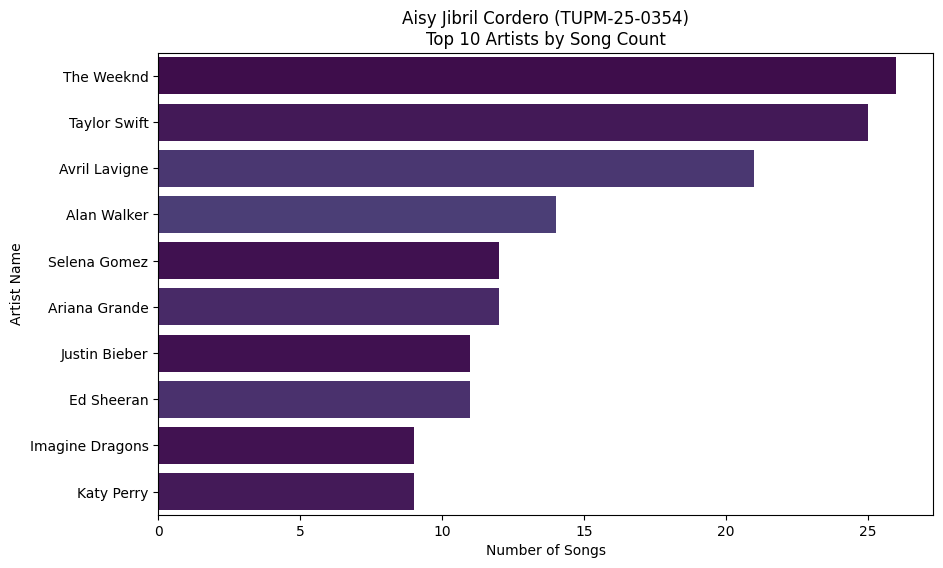

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    y='artist', 
    data=df,
    order=df['artist'].value_counts().head(10).index, 
    palette='viridis',
    hue='artist',
    legend=False
)

plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count")
plt.xlabel("Number of Songs")
plt.ylabel("Artist Name")

plt.show()

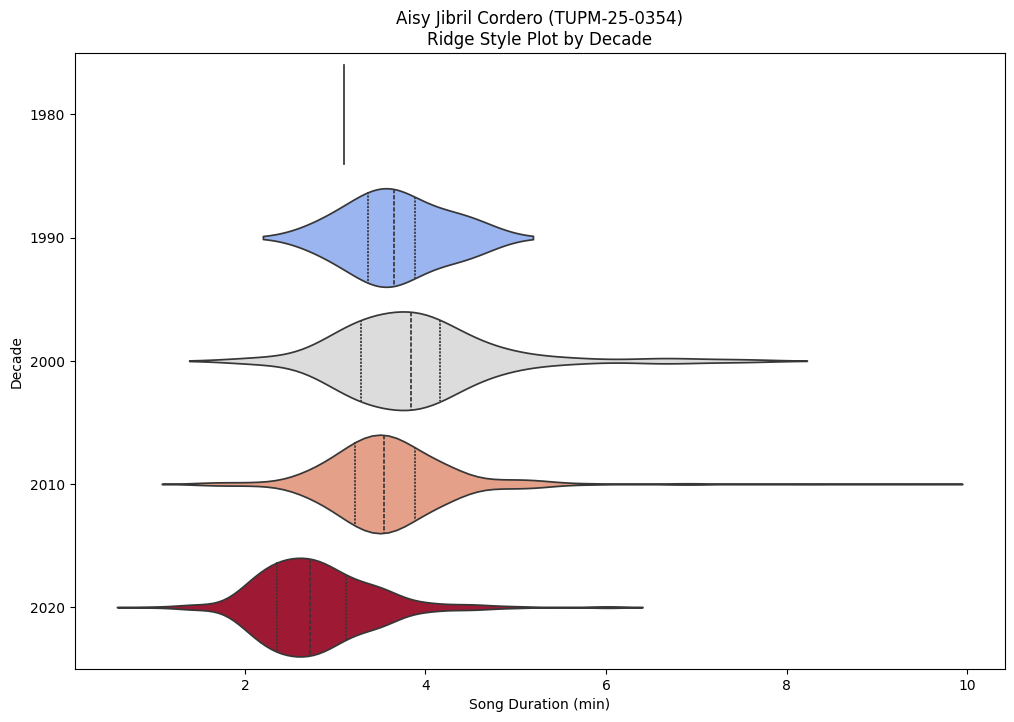

In [ ]:
plt.figure(figsize=(12, 8))

sns.violinplot(
    data=df, 
    x='duration_min', 
    y='decade', 
    orient='h',            
    palette='coolwarm', 
    inner='quartile',      
    hue='decade',          
    legend=False
)


plt.title(f"{student_name} ({student_id})\nRidge Style Plot by Decade")
plt.xlabel("Song Duration (min)")
plt.ylabel("Decade")

plt.show()

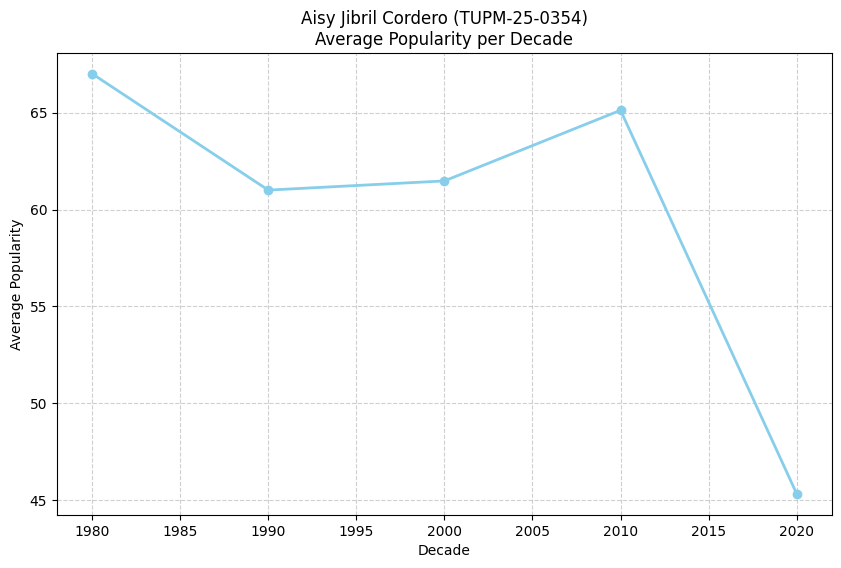

In [ ]:
avg_pop = df.groupby('decade')['popularity'].mean()

plt.figure(figsize=(10, 6))
avg_pop.plot(kind='line', color=color1, marker='o', linewidth=2)

plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade")
plt.xlabel('Decade')
plt.ylabel('Average Popularity')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

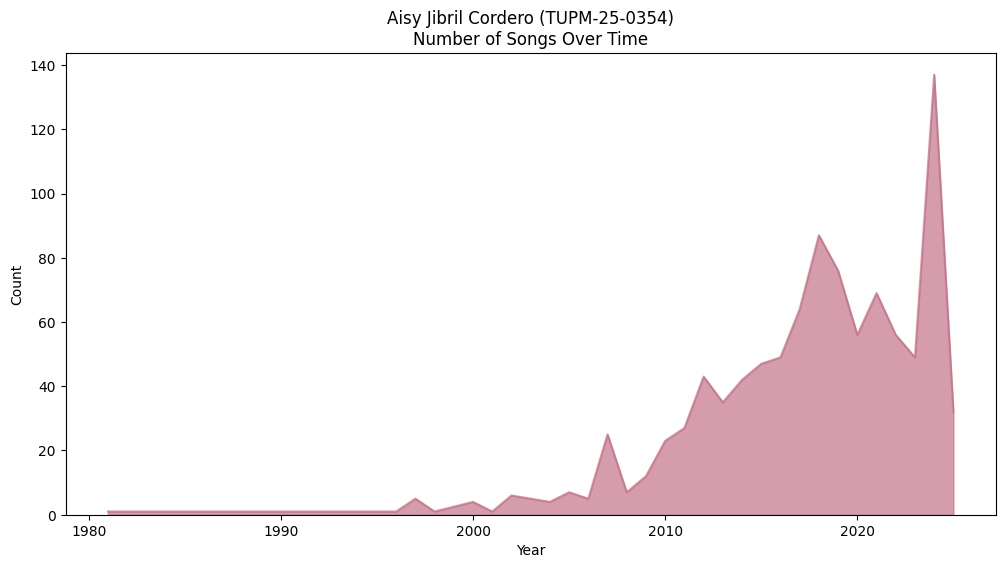

In [ ]:
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
count_by_year = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
count_by_year.plot(kind='area', color=color2, alpha=0.7)

plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time")
plt.xlabel('Year')
plt.ylabel('Count')

plt.show()

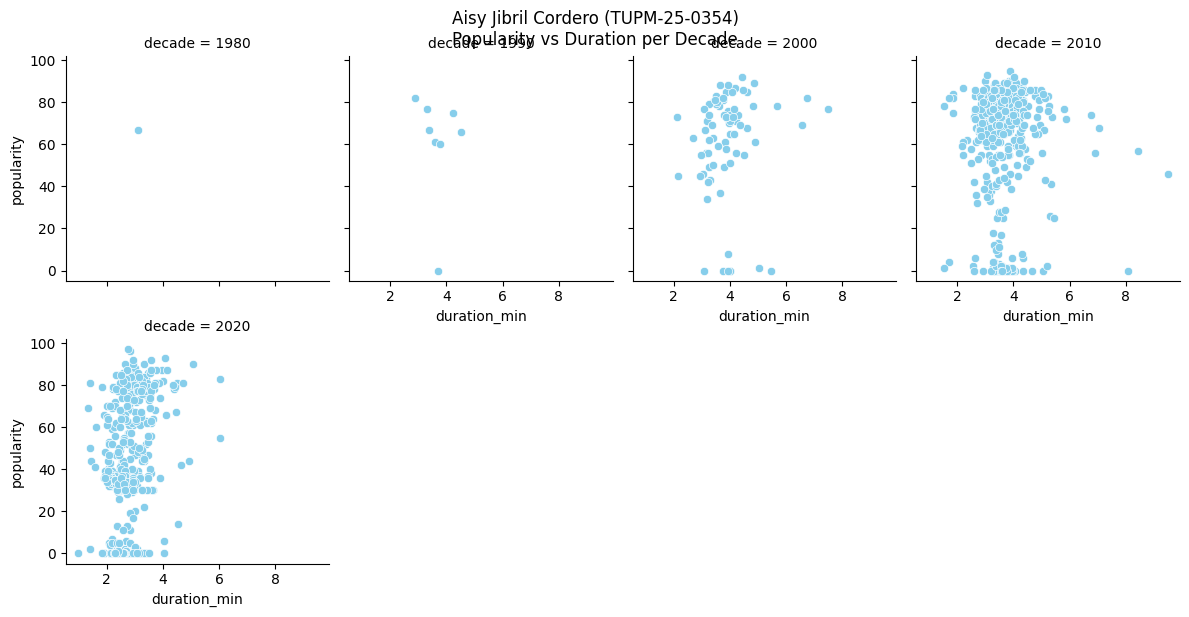

In [ ]:
g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3)

g.map_dataframe(sns.scatterplot, x='duration_min', y='popularity', color=color1)

g.fig.suptitle(f"{student_name} ({student_id})\nPopularity vs Duration per Decade", y=1.02)

plt.show()

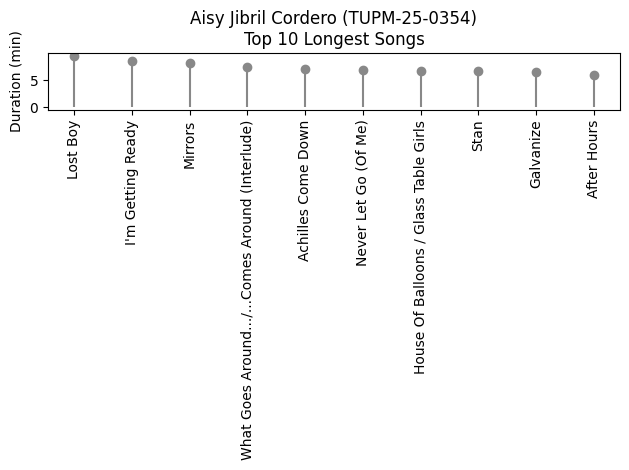

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

student_name = "Aisy Jibril Cordero"
student_id = "TUPM-25-0354"

longest = df.nlargest(10, 'duration_min')

plt.stem(longest['track_name'], longest['duration_min'],
         linefmt='#888888', markerfmt='o', basefmt=" ")


plt.xticks(rotation=90)
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs")
plt.ylabel('Duration (min)')

plt.tight_layout()

plt.show()

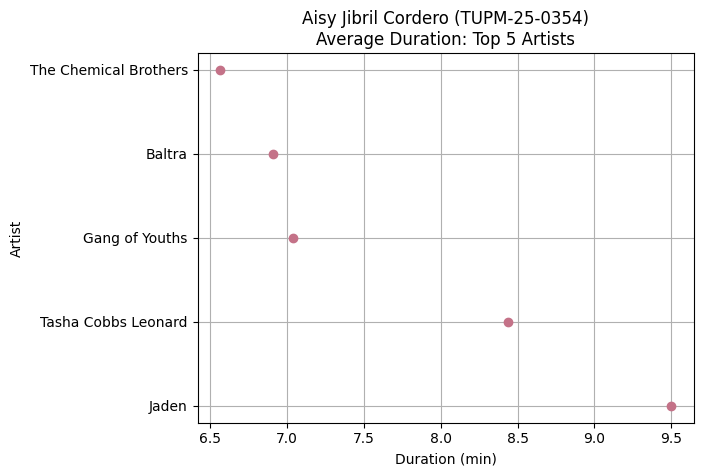

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5)


plt.plot(avg_duration.values, avg_duration.index, 'o', color=color2)


plt.title(f"Aisy Jibril Cordero (TUPM-25-0354)\nAverage Duration: Top 5 Artists")
plt.xlabel('Duration (min)')
plt.ylabel('Artist') 


plt.grid(True)
plt.show()

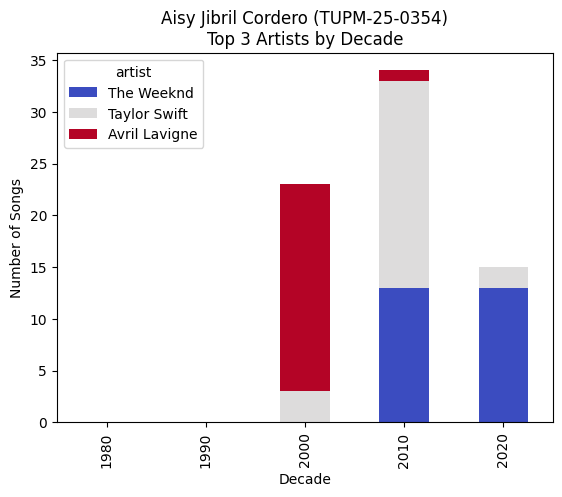

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

crosstab = pd.crosstab(df['decade'], df['artist'])

top3 = df['artist'].value_counts().head(3).index

crosstab[top3].plot(kind='bar', stacked=True, colormap='coolwarm')

plt.title(f"Aisy Jibril Cordero (TUPM-25-0354)\nTop 3 Artists by Decade")
plt.ylabel('Number of Songs')
plt.xlabel('Decade')

plt.show()

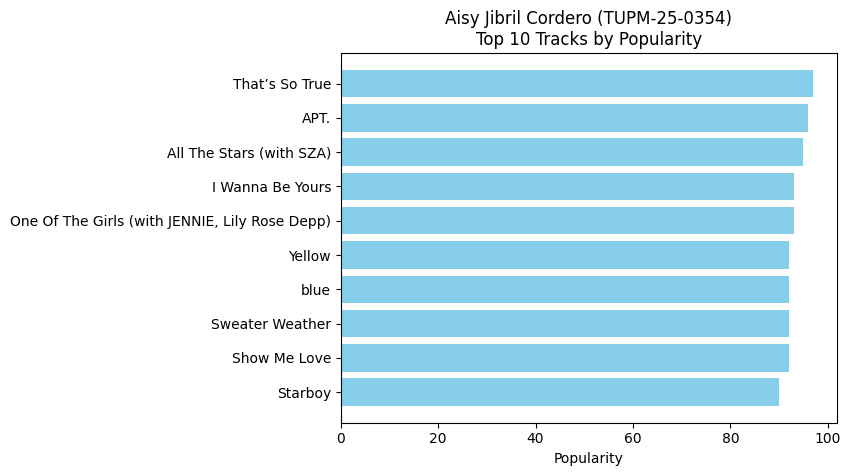

In [ ]:
import matplotlib.pyplot as plt

top_tracks = df.nlargest(10, 'popularity')

plt.barh(top_tracks['track_name'], top_tracks['popularity'], color=color1)

plt.xlabel('Popularity')
plt.title(f"Aisy Jibril Cordero (TUPM-25-0354)\nTop 10 Tracks by Popularity")

plt.gca().invert_yaxis()

plt.show()

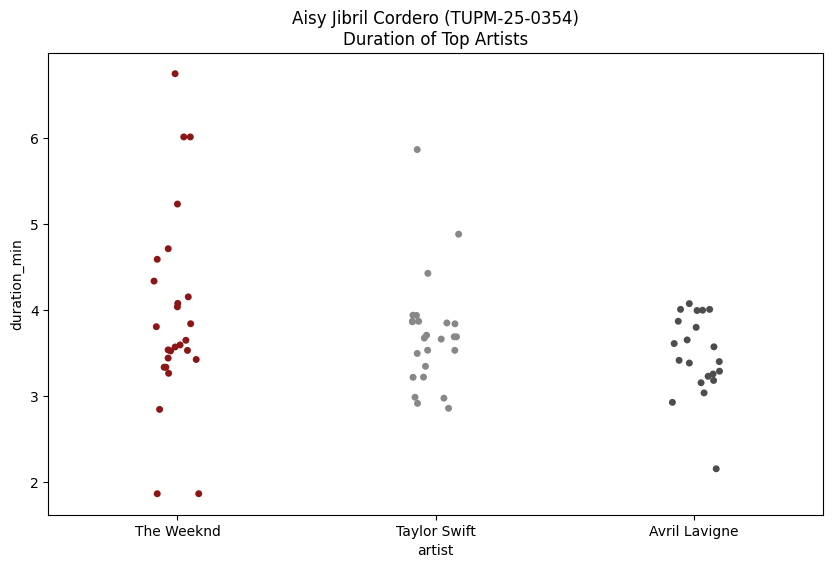

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Identify the top 3 artists
top_artists = df['artist'].value_counts().head(3).index

# 2. Create the Plot
plt.figure(figsize=(10, 6))

sns.stripplot(
    data=df[df['artist'].isin(top_artists)], 
    x='artist', 
    y='duration_min', 
    # FIX 1: Provide 3 colors for 3 artists
    palette=['#8C1515', '#888888', '#4D4D4D'], 
    # FIX 2: Assign 'artist' to hue to stop the FutureWarning
    hue='artist',
    # FIX 3: Hide the redundant legend
    legend=False
)

plt.title(f"Aisy Jibril Cordero (TUPM-25-0354)\nDuration of Top Artists")
plt.show()

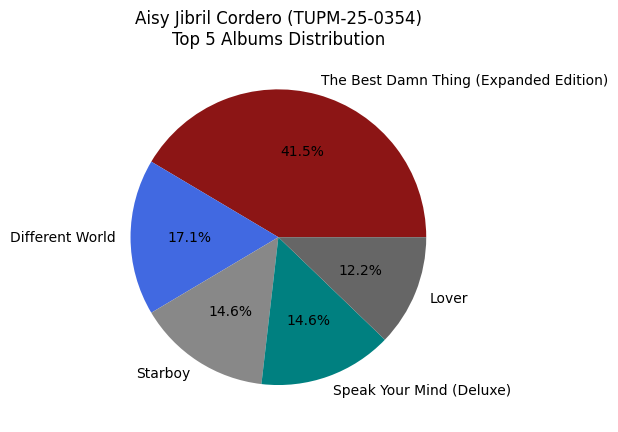

In [9]:
import matplotlib.pyplot as plt

top_albums = df['album'].value_counts().head(5)

colors = ['#8C1515', color1, '#888888', color2, '#666666']

plt.pie(top_albums, 
        labels=top_albums.index, 
        autopct='%1.1f%%', 
        colors=colors)

plt.title(f"Aisy Jibril Cordero (TUPM-25-0354)\nTop 5 Albums Distribution")

plt.show()

In [ ]:
%pip install scipy

   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   -- ------------------------------------- 2.4/37.3 MB 13.5 MB/s eta 0:00:03
   ------ --------------------------------- 6.0/37.3 MB 15.6 MB/s eta 0:00:03
   ---------- ----------------------------- 9.4/37.3 MB 16.0 MB/s eta 0:00:02
   ------------- -------------------------- 12.8/37.3 MB 16.1 MB/s eta 0:00:02
   ----------------- ---------------------- 16.0/37.3 MB 16.0 MB/s eta 0:00:02
   -------------------- ------------------- 19.4/37.3 MB 16.0 MB/s eta 0:00:02
   ----------------------- ---------------- 22.3/37.3 MB 15.7 MB/s eta 0:00:01
   --------------------------- ------------ 25.4/37.3 MB 15.6 MB/s eta 0:00:01
   ------------------------------ --------- 28.6/37.3 MB 15.6 MB/s eta 0:00:01
   ---------------------------------- ----- 32.0/37.3 MB 15.7 MB/s eta 0:00:01
   ------------------------------------- -- 35.1/37.3 MB 15.7 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 15.4 MB

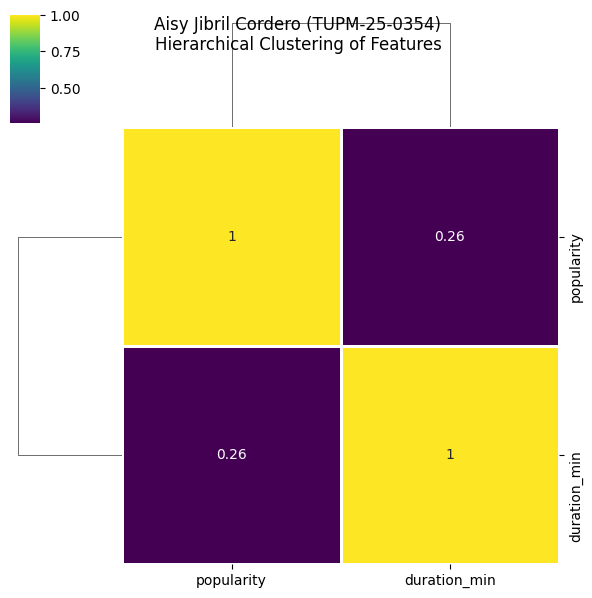

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('spotify_top_1000_tracks.csv')

numerical_cols = ['popularity', 'duration_min']
df_numeric = df[numerical_cols].dropna()

sns.clustermap(
    df_numeric.corr(), 
    annot=True, 
    cmap='viridis', 
    linewidths=.75, 
    figsize=(6, 6)
)

plt.suptitle(f"Aisy Jibril Cordero (TUPM-25-0354)\nHierarchical Clustering of Features")

plt.show()

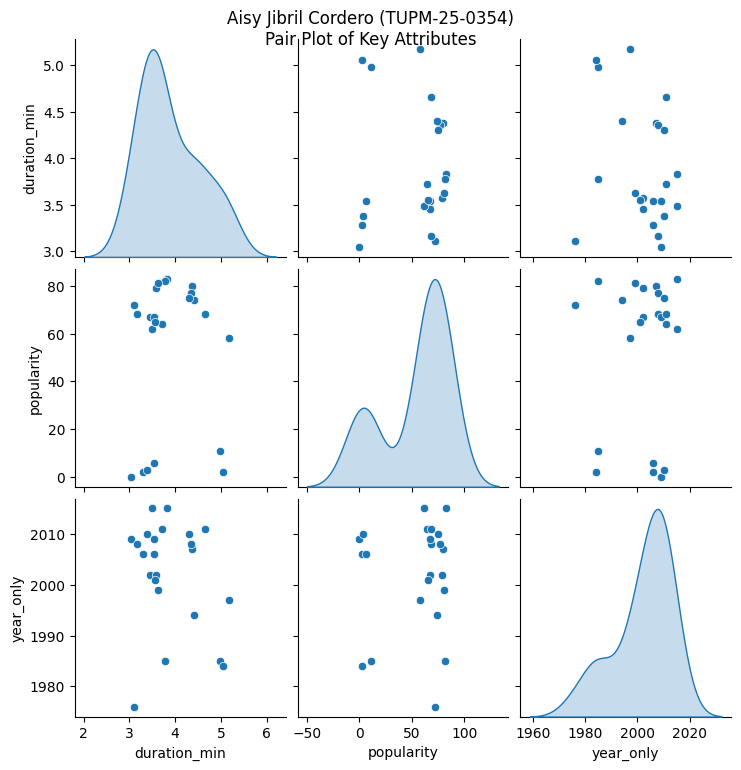

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('spotify_top_1000_tracks.csv')

df['year_only'] = pd.to_numeric(df['release_date'], errors='coerce')
df_clean = df.dropna(subset=['year_only', 'popularity', 'duration_min'])

sns.pairplot(df_clean[['duration_min', 'popularity', 'year_only']], diag_kind='kde')

plt.suptitle(f"Aisy Jibril Cordero (TUPM-25-0354)\nPair Plot of Key Attributes", y=1.02)

plt.show()

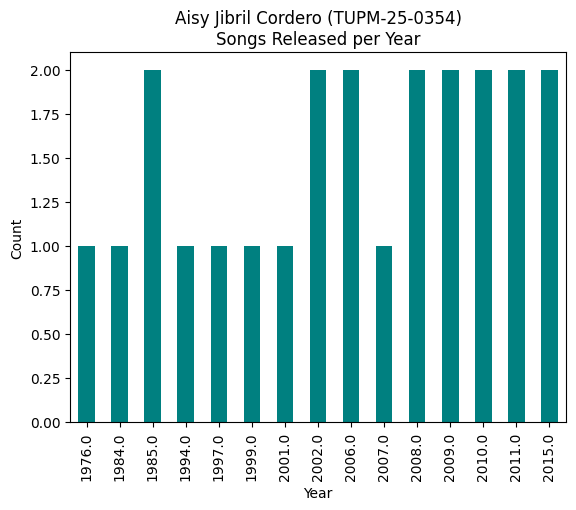

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('spotify_top_1000_tracks.csv')

color2 = 'teal' 

df['release_year'] = pd.to_numeric(df['release_date'], errors='coerce')

df['release_year'].value_counts().sort_index().plot(kind='bar', color=color2)

plt.title(f"Aisy Jibril Cordero (TUPM-25-0354)\nSongs Released per Year")
plt.ylabel('Count')
plt.xlabel('Year')

plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_39856\525484223.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm')


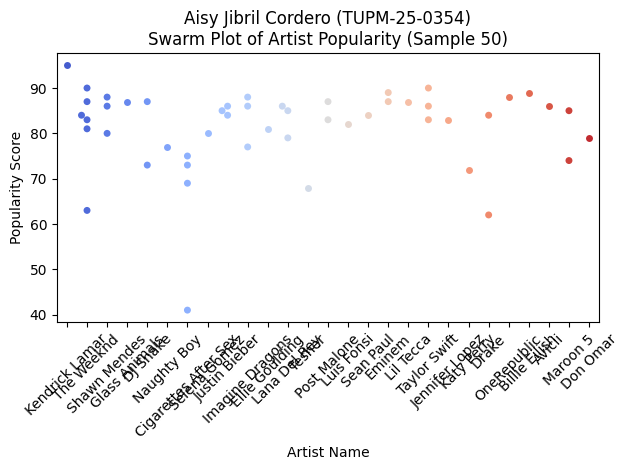

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('spotify_top_1000_tracks.csv')

sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm')

plt.title(f"Aisy Jibril Cordero (TUPM-25-0354)\nSwarm Plot of Artist Popularity (Sample 50)")
plt.xticks(rotation=45) 
plt.ylabel('Popularity Score')
plt.xlabel('Artist Name')

plt.tight_layout() 
plt.show()

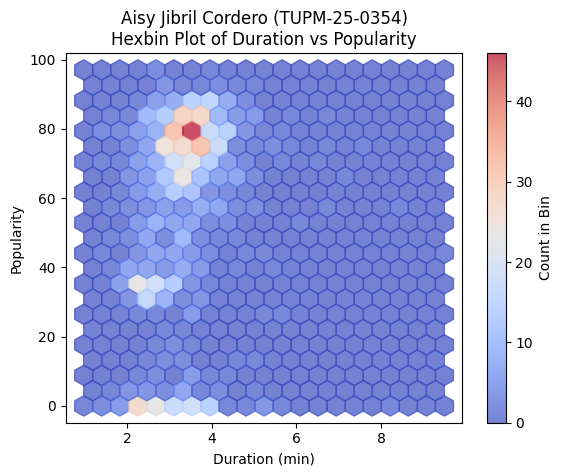

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('spotify_top_1000_tracks.csv')

plt.hexbin(df['duration_min'], df['popularity'], gridsize=20, cmap='coolwarm', alpha=0.7)

plt.title(f"Aisy Jibril Cordero (TUPM-25-0354)\nHexbin Plot of Duration vs Popularity")
plt.xlabel('Duration (min)')
plt.ylabel('Popularity')

plt.colorbar(label='Count in Bin')
plt.show()

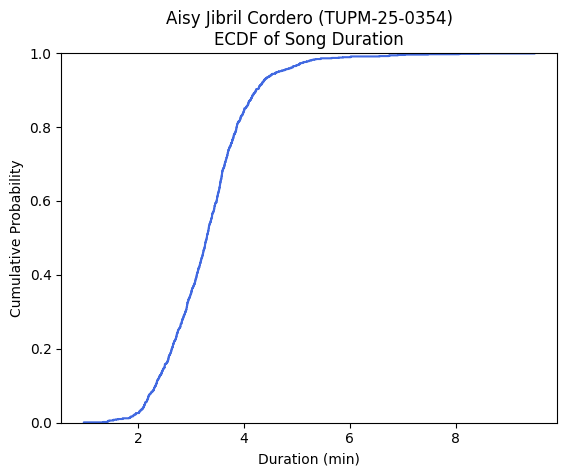

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('spotify_top_1000_tracks.csv')

color1 = 'royalblue'
student_name = "Aisy Jibril Cordero"
student_id = "TUPM-25-0354"

sns.ecdfplot(data=df, x='duration_min', color=color1)

plt.title(f"{student_name} ({student_id})\nECDF of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Cumulative Probability')

plt.show()

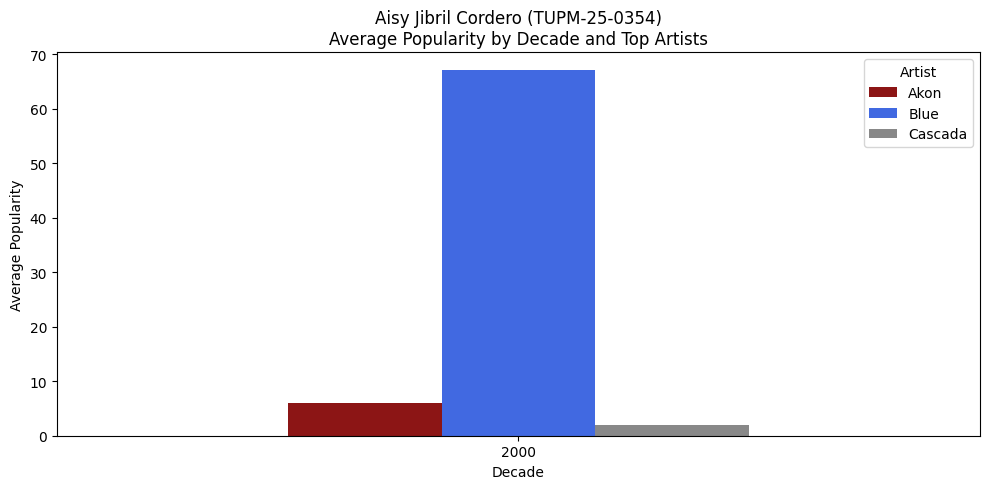

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('spotify_top_1000_tracks.csv')

df['release_year'] = pd.to_numeric(df['release_date'], errors='coerce')
df = df.dropna(subset=['release_year', 'popularity'])

df['decade'] = (df['release_year'] // 10).astype(int) * 10

top3 = df['artist'].value_counts().head(3).index

df_top3 = df[df['artist'].isin(top3)]
avg_artist_decade = df_top3.groupby(['decade', 'artist'])['popularity'].mean().unstack().fillna(0)

if not avg_artist_decade.empty:
    avg_artist_decade.plot(kind='bar', figsize=(10, 5), color=['#8C1515', 'royalblue', '#888888'])
    
    plt.title(f"Aisy Jibril Cordero (TUPM-25-0354)\nAverage Popularity by Decade and Top Artists")
    plt.ylabel('Average Popularity')
    plt.xlabel('Decade')
    plt.legend(title='Artist')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Error: No numeric data available for the selected artists and decades.")